# Avance 1 - Preparacion de datos previo EDA

**Objetivo**: preparar e integrar las diferentes fuentes de datos disponibles para el proyecto de estimacion de ingresos.

Antes de realizar el análisis exploratorio de datos (EDA), se ejecutan tareas de lectura, limpieza, validación de llaves, transformación de variables y consolidacion de un dataframe maestro o final.

Las fuentes utilizadas son:

- Datos de nomina
- Datos sociodemograficos
- Datos de direcciones
- Datos de coordenadas
- Datos de movilidad derivados de Google Maps

**2. Libreras**

In [2]:
import pandas as pd
import numpy as np
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 80)

**3. Lectura de archivos**

In [25]:
path = r"C:\Users\cesar\Downloads\DataBaseAfirme"


df_nomina = pd.read_csv(
    f"{path}\\bd_datos_nomima.txt",
    sep="|",
    encoding="latin1"
)

df_socio = pd.read_csv(
    f"{path}\\bd_datos_sociodemograficos.txt",
    sep="|",
    encoding="latin1"
)

df_direcciones = pd.read_csv(
    f"{path}\\bd_poblacion_direcciones.txt",
    sep="|",
    encoding="latin1"
)

df_coord = pd.read_csv(
    f"{path}\\bd_poblacion_coordenadas.txt",
    sep="|",
    encoding="latin1"
)

cols_maps = [
    "vect_dist_clean",
    "text_busq_st_code_traffic_clean",
    "text_busq_min_time_clean",
    "text_busq_max_time_clean",
    "direccion_afirme",
    "TRACUN"
]

df_maps = pd.read_csv(
    f"{path}\\info_110526.txt",
    sep="|",
    encoding="latin1",
    usecols=cols_maps
)


print(df_nomina.shape)
print(df_socio.shape)
print(df_direcciones.shape)
print(df_coord.shape)
print(df_maps.shape)

C:\Users\cesar\AppData\Local\Temp\ipykernel_40384\1974158673.py:16: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_direcciones = pd.read_csv(


(395817, 10)
(410308, 5)
(410308, 12)
(393376, 5)
(3497800, 6)


**4. Exploracion inicial de estructura**

In [ ]:
def resumen_estructura(nombre, df):
    print("=" * 70)
    print(f"DATAFRAME: {nombre}")
    print("=" * 70)
    print(f"Filas: {df.shape[0]:,}")
    print(f"Columnas: {df.shape[1]:,}")
    print("\nColumnas:")
    print(df.columns.tolist())
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nPrimeros registros:")
    display(df.head(3))

resumen_estructura("Nomina", df_nomina)
resumen_estructura("Sociodemografico", df_socio)
resumen_estructura("Direcciones", df_direcciones)
resumen_estructura("Coordenadas", df_coord)
resumen_estructura("Google Maps", df_maps)

DATAFRAME: Nomina
Filas: 395,817
Columnas: 10

Columnas:
['NUM_EMPRESAS', 'MEDIANA_DAYS_FREQ', 'AVG_DAYS_FREQ', 'MEDIANA_ING_MENSUAL', 'AVG_ING_MENSUAL', 'FECHA_FIRST_DEPOSITO', 'MONTH_LAST_DEPOSITO', 'FECHA_RANGO_IZQ', 'FECHA_LAST_DEPOSITO', 'TRACUN']

Tipos de datos:
NUM_EMPRESAS              int64
MEDIANA_DAYS_FREQ       float64
AVG_DAYS_FREQ           float64
MEDIANA_ING_MENSUAL     float64
AVG_ING_MENSUAL         float64
FECHA_FIRST_DEPOSITO     object
MONTH_LAST_DEPOSITO      object
FECHA_RANGO_IZQ          object
FECHA_LAST_DEPOSITO      object
TRACUN                    int64
dtype: object

Primeros registros:


,NUM_EMPRESAS,MEDIANA_DAYS_FREQ,AVG_DAYS_FREQ,MEDIANA_ING_MENSUAL,AVG_ING_MENSUAL,FECHA_FIRST_DEPOSITO,MONTH_LAST_DEPOSITO,FECHA_RANGO_IZQ,FECHA_LAST_DEPOSITO,TRACUN
0,0,30.0,30.400000,3856.81,4285.186000,2015-01-02,2026-03-01,2025-03-01,2026-03-31,253502
1,1,15.0,15.315789,7745.80,8101.263158,2015-01-14,2026-03-01,2025-03-01,2026-03-31,976759
2,1,15.0,14.466667,11655.20,11643.901333,2015-09-28,2026-03-01,2025-03-01,2026-03-27,2064509


DATAFRAME: Sociodemografico
Filas: 410,308
Columnas: 5

Columnas:
['SEXO', 'ESTADO_CIVIL', 'FECHA_NACIMIENTO', 'FECHA_CLIENTE_DESDE', 'TRACUN']

Tipos de datos:
SEXO                   object
ESTADO_CIVIL           object
FECHA_NACIMIENTO       object
FECHA_CLIENTE_DESDE    object
TRACUN                  int64
dtype: object

Primeros registros:


,SEXO,ESTADO_CIVIL,FECHA_NACIMIENTO,FECHA_CLIENTE_DESDE,TRACUN
0,F,1,1960-05-18,2002-03-20,164228
1,M,1,1985-10-28,2005-04-07,217695
2,M,2,1960-08-18,2006-07-24,251079


DATAFRAME: Direcciones
Filas: 410,308
Columnas: 12

Columnas:
['Unnamed: 0', 'TRACUN', 'CUSNA3', 'CUSNA4', 'CUSCTY', 'CUSSTE', 'CUSZPC', 'CUSPOB', 'CUSCTR', 'CUSCCS', 'DIRECCION', 'TRACUN_MASK']

Tipos de datos:
Unnamed: 0      int64
TRACUN          int64
CUSNA3         object
CUSNA4         object
CUSCTY         object
CUSSTE         object
CUSZPC         object
CUSPOB         object
CUSCTR         object
CUSCCS         object
DIRECCION      object
TRACUN_MASK     int64
dtype: object

Primeros registros:


,Unnamed: 0,TRACUN,CUSNA3,CUSNA4,CUSCTY,CUSSTE,CUSZPC,CUSPOB,CUSCTR,CUSCCS,DIRECCION,TRACUN_MASK
0,0,954232,SIN NOMBRE S/N,LOC LA BIZNAGA,ARTEAGA,COA,25380.0,25370,MEX,MEX,"SIN NOMBRE S/N ,LOC LA BIZNAGA ,ARTE...",1021028
1,1,960232,AND DR ANGEL MARTINEZ VILLAREAL416,MARTIRES DE CANANEA,SANTA CATARINA,NL,66365.0,66365,MEX,MEX,"AND DR ANGEL MARTINEZ VILLAREAL416 ,MARTIRES DE CANANEA ,SANT...",1027448
2,2,996394,HUNGRIA 5427,VILLA OLIMPICA,GUADALUPE,NL,67180.0,67180,MEX,MEX,"HUNGRIA 5427 ,VILLA OLIMPICA ,GUAD...",1066142


DATAFRAME: Coordenadas
Filas: 394,328
Columnas: 5

Columnas:
['latitude', 'longitude', 'score', 'direccion_sugerida', 'direccion']

Tipos de datos:
latitude              float64
longitude             float64
score                 float64
direccion_sugerida     object
direccion              object
dtype: object

Primeros registros:


,latitude,longitude,score,direccion_sugerida,direccion
0,25.843098,-100.371912,99.29,"Calle San Gabriel 927, San Miguel Residencial, Ciudad General Escobedo, Gene...","SAN GABRIEL 927 ,SAN MIGUEL RESIDENCIAL ,GENERAL ESCOBEDO ,66062 ,NL"
1,25.422886,-100.909742,99.29,"Calle Zacate 140, Loma Linda, Saltillo, Coahuila De Zaragoza, 25016","ZACATE 140 ,LOMA LINDA ,SALTILLO ,25016 ,COA"
2,25.838700,-100.375900,84.16,Hacienda La Providencia,"RIO DUERO ,DHA LA PROVIDENCIA 6 ,GENERAL ESCOBEDO ,66062 ,NL"


DATAFRAME: Google Maps
Filas: 3,497,908
Columnas: 6

Columnas:
['vect_dist_clean', 'text_busq_st_code_traffic_clean', 'text_busq_min_time_clean', 'text_busq_max_time_clean', 'direccion_afirme', 'TRACUN']

Tipos de datos:
vect_dist_clean                     object
text_busq_st_code_traffic_clean     object
text_busq_min_time_clean            object
text_busq_max_time_clean            object
direccion_afirme                    object
TRACUN                             float64
dtype: object

Primeros registros:


,vect_dist_clean,text_busq_st_code_traffic_clean,text_busq_min_time_clean,text_busq_max_time_clean,direccion_afirme,TRACUN
0,9.8 km,medium,18 min,40 min,"- 10A CALLE PTE 133 ,COL MIGUEL ALEMAN ,SAN NICOLAS DE LOS GARZA ,66470 ,NL",5664230.0
1,11.3 km,medium,18 min,40 min,"- 10A CALLE PTE 133 ,COL MIGUEL ALEMAN ,SAN NICOLAS DE LOS GARZA ,66470 ,NL",5664230.0
2,18.8 km,light,28 min,55 min,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634.0


**5. Limpieza de nombres y llaves**

In [26]:
df_nomina = df_nomina.rename(columns={"TRACUN": "NUMERO_CLIENTE"})
df_socio = df_socio.rename(columns={"TRACUN": "NUMERO_CLIENTE"})
df_maps = df_maps.rename(columns={"TRACUN": "NUMERO_CLIENTE"})

In [34]:
#columnas que no se usaran
df_direcciones = df_direcciones.drop(
    columns=["Unnamed: 0", "TRACUN", "CUSCTR"],
    errors="ignore"
)

#renombrar 
df_direcciones = df_direcciones.rename(columns={
    "TRACUN_MASK": "NUMERO_CLIENTE",
    "CUSCCS": "CLAVE_PAIS",
    "CUSPOB": "CP_CALCULADO",
    "CUSZPC": "CP",
    "CUSSTE": "CODIGO_ESTADO",
    "CUSCTY": "CIUDAD",
    "CUSNA3": "CALLE",
    "CUSNA4": "COLONIA"
})

In [8]:
columnas_fecha_nomina = [
    "FECHA_FIRST_DEPOSITO",
    "MONTH_LAST_DEPOSITO",
    "FECHA_RANGO_IZQ",
    "FECHA_LAST_DEPOSITO"
]

for col in columnas_fecha_nomina:
    df_nomina[col] = pd.to_datetime(df_nomina[col], errors="coerce")

In [9]:
columnas_fecha_socio = [
    "FECHA_NACIMIENTO",
    "FECHA_CLIENTE_DESDE"
]

for col in columnas_fecha_socio:
    df_socio[col] = pd.to_datetime(df_socio[col], errors="coerce")

**6. Validacion y conversion de llaves**

In [216]:
dataframes_con_llave_cliente = {
    "df_nomina": df_nomina,
    "df_socio": df_socio,
    "df_direcciones": df_direcciones,
    "df_maps": df_maps
}

for nombre, df in dataframes_con_llave_cliente.items():
    df["NUMERO_CLIENTE"] = pd.to_numeric(df["NUMERO_CLIENTE"], errors="coerce")
    print(nombre, "nulos en NUMERO_CLIENTE:", df["NUMERO_CLIENTE"].isna().sum())
    df.dropna(subset=["NUMERO_CLIENTE"], inplace=True)
    df["NUMERO_CLIENTE"] = df["NUMERO_CLIENTE"].astype("int64")

df_nomina nulos en NUMERO_CLIENTE: 0
df_socio nulos en NUMERO_CLIENTE: 0
df_direcciones nulos en NUMERO_CLIENTE: 0
df_maps nulos en NUMERO_CLIENTE: 8


La variable `NUMERO_CLIENTE` se estandarizo como entero en todas las fuentes donde aparece. Esta validacion es cirtica porque las llaves deben tener el mismo tipo de dato antes de realizar los JOIN.

**7. Limpieza basica de direcciones**

In [10]:
df_direcciones["CP"] = (
    pd.to_numeric(df_direcciones["CP"], errors="coerce")
    .astype("Int64")
)

In [218]:
df_nomina.head(1)

,NUM_EMPRESAS,MEDIANA_DAYS_FREQ,AVG_DAYS_FREQ,MEDIANA_ING_MENSUAL,AVG_ING_MENSUAL,FECHA_FIRST_DEPOSITO,MONTH_LAST_DEPOSITO,FECHA_RANGO_IZQ,FECHA_LAST_DEPOSITO,NUMERO_CLIENTE
0,0,30.0,30.4,3856.81,4285.186,2015-01-02,2026-03-01,2025-03-01,2026-03-31,253502


In [219]:
df_socio.head(1)

,SEXO,ESTADO_CIVIL,FECHA_NACIMIENTO,FECHA_CLIENTE_DESDE,NUMERO_CLIENTE
0,F,1,1960-05-18,2002-03-20,164228


In [220]:
df_direcciones.head(1)

,CALLE,COLONIA,CIUDAD,CODIGO_ESTADO,CP,CP_CALCULADO,CLAVE_PAIS,DIRECCION,NUMERO_CLIENTE
0,SIN NOMBRE S/N,LOC LA BIZNAGA,ARTEAGA,COA,25380,25370,MEX,"SIN NOMBRE S/N ,LOC LA BIZNAGA ,ARTE...",1021028


In [221]:
df_coord.head(1)

,latitude,longitude,score,direccion_sugerida,direccion
0,25.843098,-100.371912,99.29,"Calle San Gabriel 927, San Miguel Residencial, Ciudad General Escobedo, Gene...","SAN GABRIEL 927 ,SAN MIGUEL RESIDENCIAL ,GENERAL ESCOBEDO ,66062 ,NL"


**8. Preparacion de base de datos de Google Maps**

La base de Google Maps contiene informacion de un proceso de web scraping realizado sobre direcciones de clientes. Su objetivo es sumar a el dataset con variables de movilidad y accesibilidad, tales como distancia a la sucursal bancaria mas cercana, tiempo estimado de traslado y nivel de trafico.

Estas variables pueden funcionar como proxies geograficos y de accesibilidad, ya que permiten representar que tan cerca o lejos se encuentra un cliente de una sucursal asi como las condiciones de traslado en una hora de alta demanda. Esta informacion puede ser util para el analisis exploratorio y para futuros modelos predictivos ya que la ubicacion y la movilidad pueden estar relacionadas indirectamente con caracteristicas socioeconomicas o de comportamiento financiero

In [222]:
print("Tamaño original df_maps:", df_maps.shape)
print("Duplicados:", df_maps.duplicated().sum())
print("Duplicados por cliente:", df_maps["NUMERO_CLIENTE"].duplicated().sum())

df_maps.groupby("NUMERO_CLIENTE").size().describe()

Tamaño original df_maps: (3497900, 6)
Duplicados: 2300396
Duplicados por cliente: 3332685


count    165215.000000
mean         21.171806
std          94.449404
min           1.000000
25%           1.000000
50%           6.000000
75%           9.000000
max        2198.000000
dtype: float64

Solo tenemos 165,215 clientes unicos, en promedio cada cliente tiene 21 rutas, algunos clientes llegan a tener hasta 2,198 registros

El dataset de Google Maps contiene multiples registros por cliente debido a que para una misma direccion pueden existir varias rutas, tiempos o condiciones de trafico. Por este motivo antes de integrarlo con el resto de las fuentes, es necesario reducirlo a una sola fila por cliente.

Debido a que un mismo cliente puede tener multiples registros en la base de google maps, no es conveniente integrar esta tabla directamente al dataset maestro/final. Si se hiciera un JOIN sin una agregacion previa, se duplicarian clientes y se alteraria la estructura del conjunto de datos.

Se considero utilizar unicamente la distancia o tiempo minimo, ya que estos valores representan el mejor escenario posible. Sin embargo esta decision podria introducir un sesgo optimista porque asumiria que el cliente siempre enfrenta la ruta mas favorable

Por esta razon, se decidio generar variables agregadas a nivel cliente mediante estadisticas minimas, promedio y maximas. El minimo representa la mejor condición de accesibilidad, el promedio representa una condicion tipica y el maximo representa el peor escenario observado. Para la variable categorica de trafico se utilizo la moda porque permite conservar la condicion de trafico mas frecuente para cada cliente.

Eliminar duplicados exactos:

In [27]:
df_maps = df_maps.drop_duplicates()

print("Tamaño despues de eliminar:", df_maps.shape)

Tamaño despues de eliminar: (1197461, 6)


Convertir distancia y tiempos

In [12]:
def distancia_a_km(valor):
    valor = str(valor).strip().lower()
    
    if "km" in valor:
        return float(valor.replace("km", "").strip())
    
    elif "metro" in valor:
        metros = float(valor.replace("metros", "").replace("metro", "").strip())
        return metros / 1000
    
    else:
        return np.nan

In [13]:
import re

def tiempo_a_minutos(valor):
    valor = str(valor).strip().lower()
    
    horas = 0
    minutos = 0
    match_horas = re.search(r"(\d+)\s*h", valor)
    match_minutos = re.search(r"(\d+)\s*min", valor)
    
    if match_horas:
        horas = int(match_horas.group(1))
    
    if match_minutos:
        minutos = int(match_minutos.group(1))
    
    if match_horas or match_minutos:
        return horas * 60 + minutos
    
    return np.nan

In [28]:
df_maps["distancia_km"] = df_maps["vect_dist_clean"].apply(distancia_a_km)
df_maps["tiempo_min_minutos"] = df_maps["text_busq_min_time_clean"].apply(tiempo_a_minutos)
df_maps["tiempo_max_minutos"] = df_maps["text_busq_max_time_clean"].apply(tiempo_a_minutos)

In [227]:
df_maps.head()

,vect_dist_clean,text_busq_st_code_traffic_clean,text_busq_min_time_clean,text_busq_max_time_clean,direccion_afirme,NUMERO_CLIENTE,distancia_km,tiempo_min_minutos,tiempo_max_minutos
0,9.8 km,medium,18 min,40 min,"- 10A CALLE PTE 133 ,COL MIGUEL ALEMAN ,SAN NICOLAS DE LOS GARZA ,66470 ,NL",5664230,9.8,18.0,40.0
1,11.3 km,medium,18 min,40 min,"- 10A CALLE PTE 133 ,COL MIGUEL ALEMAN ,SAN NICOLAS DE LOS GARZA ,66470 ,NL",5664230,11.3,18.0,40.0
2,18.8 km,light,28 min,55 min,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,18.8,28.0,55.0
3,18.8 km,light,30 min,1 h,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,18.8,30.0,60.0
4,18.8 km,light,30 min,1 h 5 min,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,18.8,30.0,65.0


**9. Agregacion por cliente**

In [16]:
def moda(serie):
    conteos = serie.value_counts()
    
    if len(conteos) == 0:
        return np.nan
    
    return conteos.index[0]

In [29]:
#PRUEBA, NO CORRER

df_dist = df_maps.groupby("NUMERO_CLIENTE")["distancia_km"].agg(["min", "mean", "max"]).reset_index()

df_dist = df_dist.rename(columns={
    "min": "dist_min_km",
    "mean": "dist_mean_km",
    "max": "dist_max_km"
})

df_time_min = df_maps.groupby("NUMERO_CLIENTE")["tiempo_min_minutos"].agg(["min", "mean"]).reset_index()

df_time_min = df_time_min.rename(columns={
    "min": "time_min_min",
    "mean": "time_min_mean"
})
df_time_max = df_maps.groupby("NUMERO_CLIENTE")["tiempo_max_minutos"].agg(["max", "mean"]).reset_index()

df_time_max = df_time_max.rename(columns={
    "max": "time_max_max",
    "mean": "time_max_mean"
})

df_traffic = df_maps.groupby("NUMERO_CLIENTE")["text_busq_st_code_traffic_clean"].apply(moda).reset_index()

df_traffic = df_traffic.rename(columns={
    "text_busq_st_code_traffic_clean": "traffic_mode"
})

df_maps_agg_alt = (
    df_dist
    .merge(df_time_min, on="NUMERO_CLIENTE", how="left")
    .merge(df_time_max, on="NUMERO_CLIENTE", how="left")
    .merge(df_traffic, on="NUMERO_CLIENTE", how="left")
)

In [30]:
df_maps_agg = df_maps.groupby("NUMERO_CLIENTE", sort=False).agg(
    dist_min_km=("distancia_km", "min"),
    dist_mean_km=("distancia_km", "mean"),
    dist_max_km=("distancia_km", "max"),
    
    time_min_min=("tiempo_min_minutos", "min"),
    time_min_mean=("tiempo_min_minutos", "mean"),
    
    time_max_max=("tiempo_max_minutos", "max"),
    time_max_mean=("tiempo_max_minutos", "mean"),
    
    traffic_mode=("text_busq_st_code_traffic_clean", moda)
).reset_index()

In [ ]:
df_maps_agg.head()

,NUMERO_CLIENTE,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode
0,5664230,9.8,10.55,11.3,18.0,18.000000,40.0,40.0,medium
1,4831634,18.8,20.30,21.2,28.0,29.333333,65.0,60.0,medium
2,6291464,4.1,4.25,4.4,9.0,9.000000,26.0,26.0,hard
3,6452110,4.1,4.25,4.4,9.0,9.000000,26.0,26.0,hard
4,6095489,4.1,4.25,4.4,9.0,9.000000,26.0,26.0,hard


**10. Ejemplo antes y despues**

In [19]:
cliente = 5664230

df_maps[df_maps["NUMERO_CLIENTE"] == cliente]

,vect_dist_clean,text_busq_st_code_traffic_clean,text_busq_min_time_clean,text_busq_max_time_clean,direccion_afirme,NUMERO_CLIENTE,distancia_km,tiempo_min_minutos,tiempo_max_minutos
0,9.8 km,medium,18 min,40 min,"- 10A CALLE PTE 133 ,COL MIGUEL ALEMAN ,SAN NICOLAS DE LOS GARZA ,66470 ,NL",5664230.0,9.8,18.0,40.0
1,11.3 km,medium,18 min,40 min,"- 10A CALLE PTE 133 ,COL MIGUEL ALEMAN ,SAN NICOLAS DE LOS GARZA ,66470 ,NL",5664230.0,11.3,18.0,40.0


In [20]:
df_maps_agg[df_maps_agg["NUMERO_CLIENTE"] == cliente]

,NUMERO_CLIENTE,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode
0,5664230.0,9.8,10.55,11.3,18.0,18.0,40.0,40.0,medium


Para el cliente seleccionado, los registros originales muestran diferentes rutas hacia una sucursal bancaria. Despues de la agregacion estos registros se resumen en una sola fila que conserva la distancia minima, promedio y maxima asi como el tiempo minimo, promedio y maximo. Esto permitee integrar la informacion de movilidad al dataset maestro7Final sin duplicar clientes.

**dist_min_km (9.8 km)** es la sucursal mas cercana

**dist_mean_km (10.55 km)** es ladistancia mas tipica

**dist_max_km (11.3 km)** es la peor alternativa

**time_min_min (18 min)** es la mejor escenario en tiempo

**time_max_max (40 min)** es el peor trafico que se tiene

In [229]:
cliente2 = 4831634

df_maps[df_maps["NUMERO_CLIENTE"] == cliente2]

,vect_dist_clean,text_busq_st_code_traffic_clean,text_busq_min_time_clean,text_busq_max_time_clean,direccion_afirme,NUMERO_CLIENTE,distancia_km,tiempo_min_minutos,tiempo_max_minutos
2,18.8 km,light,28 min,55 min,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,18.8,28.0,55.0
3,18.8 km,light,30 min,1 h,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,18.8,30.0,60.0
4,18.8 km,light,30 min,1 h 5 min,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,18.8,30.0,65.0
5,20.9 km,medium,28 min,55 min,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,20.9,28.0,55.0
6,20.9 km,medium,30 min,1 h,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,20.9,30.0,60.0
7,20.9 km,medium,30 min,1 h 5 min,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,20.9,30.0,65.0
8,21.2 km,medium,28 min,55 min,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,21.2,28.0,55.0
9,21.2 km,medium,30 min,1 h,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,21.2,30.0,60.0
10,21.2 km,medium,30 min,1 h 5 min,"- 1A CDA DE PLUTARCO E CALLES 9 A ,VALLE DE ANAHUAC SECCION A ,ECATEPEC DE M...",4831634,21.2,30.0,65.0


In [230]:
df_maps_agg[df_maps_agg["NUMERO_CLIENTE"] == cliente2]

,NUMERO_CLIENTE,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode
1,4831634,18.8,20.3,21.2,28.0,29.333333,65.0,60.0,medium


**11. Validacion**

In [31]:
clientes_nomina = set(df_nomina["NUMERO_CLIENTE"].dropna())
clientes_maps = set(df_maps_agg["NUMERO_CLIENTE"].dropna())

clientes_comunes = clientes_nomina.intersection(clientes_maps)

print("Clientes unicos nomina:", len(clientes_nomina))
print("Clientes unicos Google Maps:", len(clientes_maps))
print("Clientes comun:", len(clientes_comunes))
print("Porcentaje de nomina con Google Maps:", round(len(clientes_comunes) / len(clientes_nomina) * 100, 2))

Clientes unicos nomina: 395817
Clientes unicos Google Maps: 164568
Clientes comun: 159828
Porcentaje de nomina con Google Maps: 40.38


Se identifico que la fuente de Google Maps cubre el 40% a todos los clientes de nomina. Esto se debe a que el proceso de scraping por el momento solo se ha ejecutado para una parte de las direcciones disponibles.

Debido a que las variables de movilidad son relevantes para el analisis, se construira una version del dataset maestro/final conservando unicamente los clientes que tienen informacion disponible en Google Maps.

**12. Integracion Data Bases**

In [41]:
df_master_base = (
    df_nomina
    .merge(df_socio, on="NUMERO_CLIENTE", how="left")
    .merge(df_direcciones, on="NUMERO_CLIENTE", how="left")
)

Coordenadas:

Antes de generar un cruce hacia la base de coordenadas haremos una variable auxiliar para cada base de datos

Estos auxiliares contemplan la direccion sin espacios para su correcto join

In [42]:
df_master_base['AUX_DIRECCION']=df_master_base['DIRECCION'].str.replace(' +','',regex=True)
df_coord['aux_direccion']=df_coord['direccion'].str.replace(' +','',regex=True)

In [43]:
df_master_base = df_master_base.merge(
    df_coord,
    left_on="AUX_DIRECCION",
    right_on="aux_direccion",
    how="left"
)

Maps

In [44]:
df_master_final = df_master_base.merge(
    df_maps_agg,
    on="NUMERO_CLIENTE",
    how="inner"
)

**13. Validaciones finales del dataset maestro/final**

In [38]:
print("Tamaño df_master_base:", df_master_base.shape)
print("Tamaño df_master_final:", df_master_final.shape)
print("Clientes duplicados:", df_master_final["NUMERO_CLIENTE"].duplicated().sum())

Tamaño df_master_base: (395817, 27)
Tamaño df_master_final: (159828, 35)
Clientes duplicados: 0


In [237]:
df_master_final.head()

,NUM_EMPRESAS,MEDIANA_DAYS_FREQ,AVG_DAYS_FREQ,MEDIANA_ING_MENSUAL,AVG_ING_MENSUAL,FECHA_FIRST_DEPOSITO,MONTH_LAST_DEPOSITO,FECHA_RANGO_IZQ,FECHA_LAST_DEPOSITO,NUMERO_CLIENTE,SEXO,ESTADO_CIVIL,FECHA_NACIMIENTO,FECHA_CLIENTE_DESDE,CALLE,COLONIA,CIUDAD,CODIGO_ESTADO,CP,CP_CALCULADO,CLAVE_PAIS,DIRECCION,latitude,longitude,score,direccion_sugerida,direccion,dist_min_km,dist_mean_km,dist_max_km,time_min_min,time_min_mean,time_max_max,time_max_mean,traffic_mode
0,1,4.0,4.940299,95002.00,105127.522388,2017-12-27,2026-03-01,2025-03-01,2026-03-30,2774786,M,2,1965-06-26,2017-09-28,BELGICA 122,RINCON DE LA SIERRA,GUADALUPE,NL,67190,67190,MEX,"BELGICA 122 ,RINCON DE LA SIERRA ,GUAD...",NaN,NaN,NaN,NaN,NaN,5.5,5.500000,5.5,12.0,12.666667,24.0,22.666667,light
1,2,15.0,15.500000,5760.00,5760.000000,2019-02-14,2026-03-01,2025-03-01,2026-03-30,3363682,M,1,1996-04-23,2019-02-11,BLAS CHUMACERO 108,ALBERTA ESCAMILLA,APODACA,NL,66640,66644,MEX,"BLAS CHUMACERO 108 ,ALBERTA ESCAMILLA ,APOD...",NaN,NaN,NaN,NaN,NaN,4.1,4.466667,4.8,10.0,10.000000,22.0,20.000000,medium
2,0,30.0,30.400000,12532.76,13761.302000,2015-01-02,2026-03-01,2025-03-01,2026-03-31,1354410,M,2,1948-05-12,2012-07-11,FORTINO GARZA CAMPOS 608,AMERICA,MONTERREY,NL,64730,NaN,MEX,"FORTINO GARZA CAMPOS 608 ,AMERICA ,MONT...",NaN,NaN,NaN,NaN,NaN,7.6,8.966667,11.4,14.0,14.666667,35.0,31.333333,medium
3,2,15.0,15.250000,14402.03,17055.690500,2015-01-14,2026-03-01,2025-03-01,2026-03-26,374501,F,1,1970-01-15,2008-06-26,NAHUATLACAS MZA 81 LT 30,AJUSCO,COYOACAN,DF,4300,NaN,MEX,"NAHUATLACAS MZA 81 LT 30 ,AJUSCO ,COYO...",NaN,NaN,NaN,NaN,NaN,97.1,97.500000,97.9,80.0,80.000000,140.0,135.000000,medium
4,1,14.0,13.764706,14071.80,13369.517647,2015-01-15,2026-03-01,2025-03-01,2026-03-27,1562303,M,1,1983-03-22,2013-06-10,SIERRA MORENA 0611,CONJ HAB LOMAS DE STA CAT,SANTA CATARINA,NL,66359,66350,MEX,"SIERRA MORENA 0611 ,CONJ HAB LOMAS DE STA CAT ,SANT...",NaN,NaN,NaN,NaN,NaN,2.0,2.200000,2.4,6.0,6.500000,10.0,10.000000,light


In [39]:
df_master_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159828 entries, 0 to 159827
Data columns (total 35 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   NUM_EMPRESAS          159828 non-null  int64  
 1   MEDIANA_DAYS_FREQ     156235 non-null  float64
 2   AVG_DAYS_FREQ         156235 non-null  float64
 3   MEDIANA_ING_MENSUAL   159828 non-null  float64
 4   AVG_ING_MENSUAL       159828 non-null  float64
 5   FECHA_FIRST_DEPOSITO  159828 non-null  object 
 6   MONTH_LAST_DEPOSITO   159828 non-null  object 
 7   FECHA_RANGO_IZQ       159828 non-null  object 
 8   FECHA_LAST_DEPOSITO   159828 non-null  object 
 9   NUMERO_CLIENTE        159828 non-null  int64  
 10  SEXO                  159828 non-null  object 
 11  ESTADO_CIVIL          159828 non-null  object 
 12  FECHA_NACIMIENTO      159825 non-null  object 
 13  FECHA_CLIENTE_DESDE   159828 non-null  object 
 14  CALLE                 159819 non-null  object 
 15  

In [45]:
df_master_final.isna().mean().sort_values(ascending=False)

traffic_mode            0.341019
dist_max_km             0.322802
dist_mean_km            0.322802
dist_min_km             0.322802
time_max_mean           0.322784
time_max_max            0.322784
time_min_mean           0.322784
time_min_min            0.322784
CP_CALCULADO            0.118579
direccion_sugerida      0.103144
score                   0.103144
longitude               0.103144
latitude                0.103144
direccion               0.084512
aux_direccion           0.084512
MEDIANA_DAYS_FREQ       0.023716
AVG_DAYS_FREQ           0.023716
COLONIA                 0.000883
CIUDAD                  0.000560
CODIGO_ESTADO           0.000085
CALLE                   0.000055
CP                      0.000030
FECHA_NACIMIENTO        0.000018
AUX_DIRECCION           0.000000
DIRECCION               0.000000
CLAVE_PAIS              0.000000
FECHA_CLIENTE_DESDE     0.000000
ESTADO_CIVIL            0.000000
SEXO                    0.000000
NUMERO_CLIENTE          0.000000
FECHA_LAST

# EDA
# 1. Estructura de los datos

En esta seccion se analizara la estructura general del dataset maestro/final (`df_master_final`), incluyendo tipos de datos, variables disponibles y valores faltantes.

Este analisis permite entender la calidad de los datos antes de aplicar tecnicas de modelado.

In [242]:
df_master_final.shape


(12707, 35)

In [46]:
df_master_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164237 entries, 0 to 164236
Data columns (total 37 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   NUM_EMPRESAS          164237 non-null  int64  
 1   MEDIANA_DAYS_FREQ     160342 non-null  float64
 2   AVG_DAYS_FREQ         160342 non-null  float64
 3   MEDIANA_ING_MENSUAL   164237 non-null  float64
 4   AVG_ING_MENSUAL       164237 non-null  float64
 5   FECHA_FIRST_DEPOSITO  164237 non-null  object 
 6   MONTH_LAST_DEPOSITO   164237 non-null  object 
 7   FECHA_RANGO_IZQ       164237 non-null  object 
 8   FECHA_LAST_DEPOSITO   164237 non-null  object 
 9   NUMERO_CLIENTE        164237 non-null  int64  
 10  SEXO                  164237 non-null  object 
 11  ESTADO_CIVIL          164237 non-null  object 
 12  FECHA_NACIMIENTO      164234 non-null  object 
 13  FECHA_CLIENTE_DESDE   164237 non-null  object 
 14  CALLE                 164228 non-null  object 
 15  

El dataset contiene 12,707 registros(clientes) y 35 variables.

Las variables incluyen:
- Variables financieras (ingresos, frecuencia de depositos)
- Variables sociodemograficas (edad, sexo, estado civil)
- Variables geograficas (direccion, estado, CP etc)
- Variables de movilidad (distancia, tiempo, trafico)

Tipos de variables

In [52]:
numericas = df_master_final.select_dtypes(include=["int64", "float64"]).columns
categoricas = df_master_final.select_dtypes(include=["object"]).columns
fechas = df_master_final.select_dtypes(include=["datetime64"]).columns

print("Numericas:", len(numericas))
print("Categoricas:", len(categoricas))
print("Fechas:", len(fechas))

Numericas: 16
Categoricas: 21
Fechas: 0


Valores faltantes

In [47]:
missing = df_master_final.isna().mean().sort_values(ascending=False)
missing.head(10)

traffic_mode          0.341019
dist_max_km           0.322802
dist_mean_km          0.322802
dist_min_km           0.322802
time_max_mean         0.322784
time_max_max          0.322784
time_min_mean         0.322784
time_min_min          0.322784
CP_CALCULADO          0.118579
direccion_sugerida    0.103144
dtype: float64

# 2. Analisis univariante

En esta sección se analiza la distribucion de las variables individuales para identificar patrones, sesgos y valores atipicos.

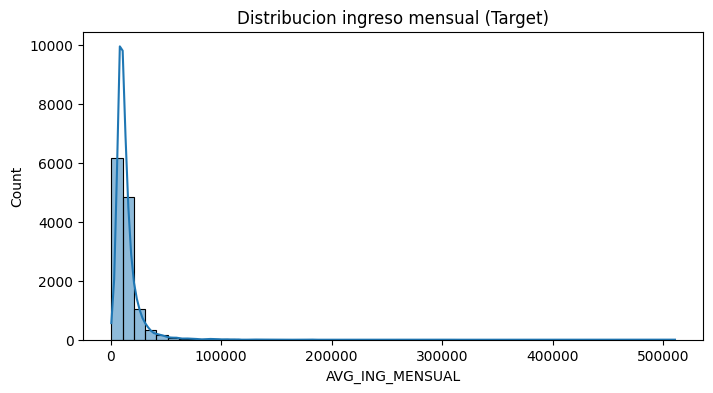

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df_master_final["AVG_ING_MENSUAL"], bins=50, kde=True)
plt.title("Distribucion ingreso mensual (Target)")
plt.show()

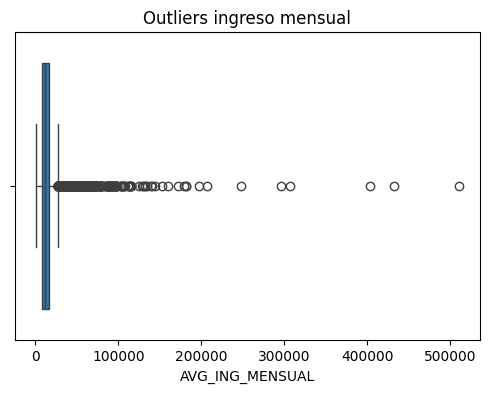

In [249]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_master_final["AVG_ING_MENSUAL"])
plt.title("Outliers ingreso mensual")
plt.show()

Se observa una distribucion sesgada a la derecha, lo cual indica la presencia de clientes con ingresos muy mayores al promedio.
Esto nos sugiere que podria ser necesario aplicar transformaciones como logaritmos en las siguientes etapas.

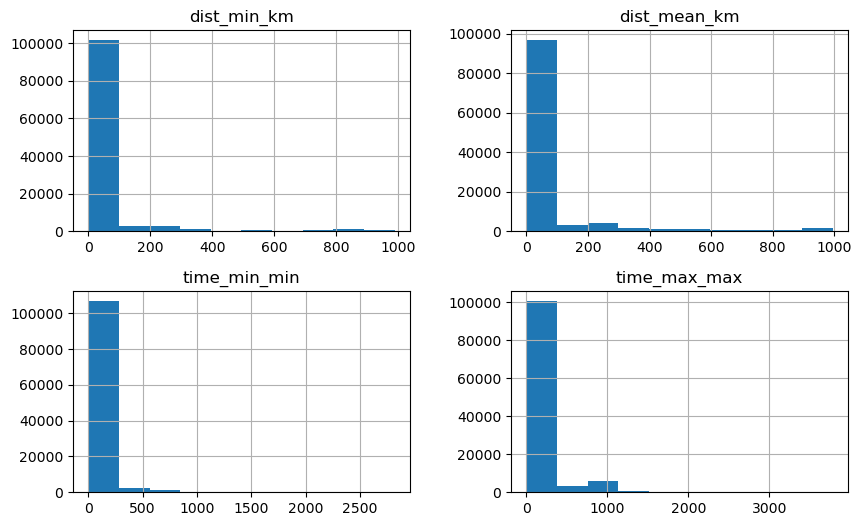

In [50]:
import matplotlib.pyplot as plt
cols = ["dist_min_km", "dist_mean_km", "time_min_min", "time_max_max"]

df_master_final[cols].hist(figsize=(10,6))
plt.show()

Se observa que las variables de distancia y tiempo presentan una distribucion altamente sesgada a la derecha. La mayoria de los clientes se encuentran relativamente cerca de una sucursal bancaria (distancias bajs y tiempos cortos), mientras que existe un grupo reducido de clientes con valores extremadamente altos.

Estos valores extremos pueden deberse a ubicaciones alejadas o a inconsistencias en los datos del scraping.

La presencia de valores extremadamente altos nos habla la existencia de outliers que podrian afectar negativamente el entrenamiento de modelos

Estos valores seran evaluados para determinar si corresponden a casos reales o errores de medicion.

# 3. Analisis bivariado y multivariado

Relaciones entre variables, especialmente la variable objetivo (ingreso).

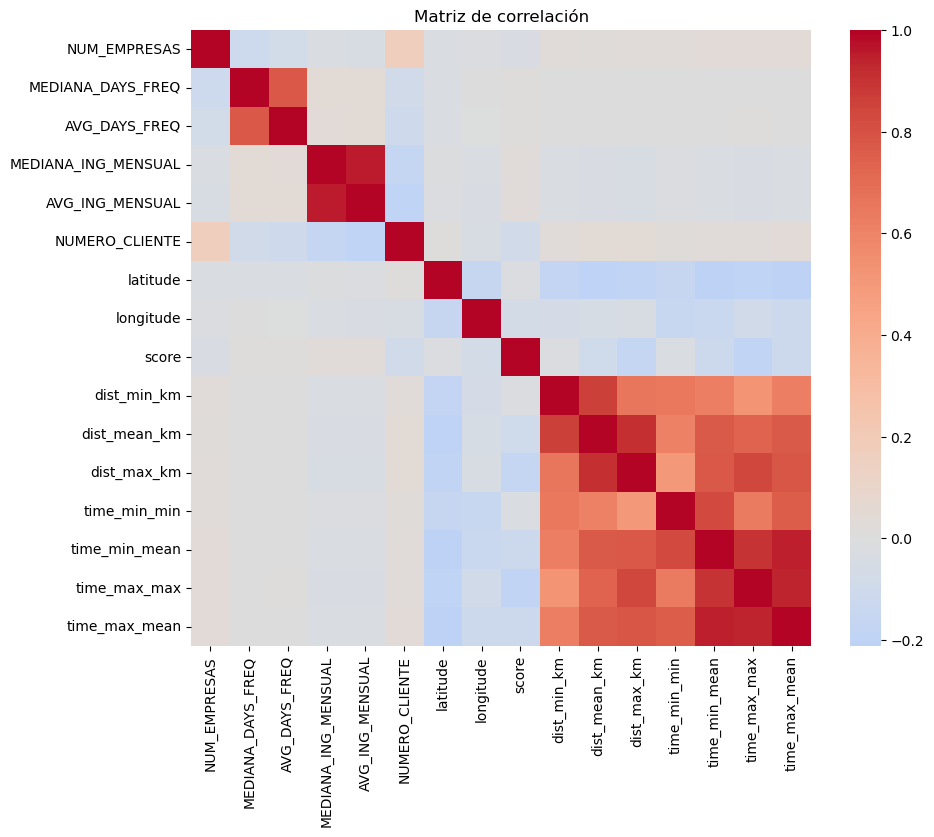

In [54]:
import seaborn as sns
corr = df_master_final[numericas].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

In [252]:
corr_target = corr["AVG_ING_MENSUAL"].sort_values(ascending=False)
corr_target

AVG_ING_MENSUAL        1.000000
MEDIANA_ING_MENSUAL    0.959691
MEDIANA_DAYS_FREQ      0.016447
dist_max_km            0.004452
dist_mean_km           0.000481
time_min_mean         -0.000551
time_max_max          -0.001738
time_max_mean         -0.002953
dist_min_km           -0.003832
time_min_min          -0.007135
AVG_DAYS_FREQ         -0.013380
CP                    -0.025594
NUM_EMPRESAS          -0.037689
NUMERO_CLIENTE        -0.104805
latitude                    NaN
longitude                   NaN
score                       NaN
Name: AVG_ING_MENSUAL, dtype: float64

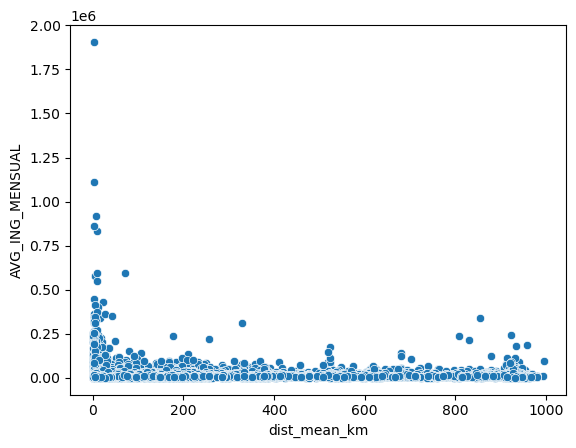

In [55]:
sns.scatterplot(
    x=df_master_final["dist_mean_km"],
    y=df_master_final["AVG_ING_MENSUAL"]
)
plt.show()

No se observa una relacion lineal clara entre la distancia promedio a la sucursal y el ingreso mensual del cliente.Se identifica una alta dispersión en los ingresos para distancias bajas, lo cual indica que la proximidad a una sucursal no es un algo plenamente determinante del nivel de ingreso.

Tambien se observan valores atipicos con ingresos extremadamente altos en distancias cercanas, lo cual reafirma la presencia de outliers en nuestra variable objetivo.

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


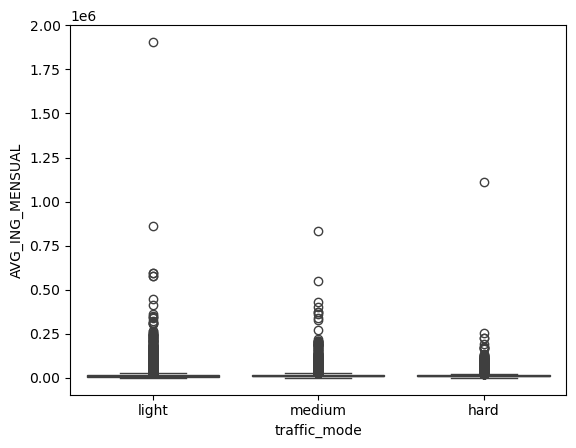

In [56]:
sns.boxplot(
    x="traffic_mode",
    y="AVG_ING_MENSUAL",
    data=df_master_final
)
plt.show()

Se observa que las distribuciones de ingreso son similares entre los distintos niveles de trafico (light, medium, hard), sin diferencias en la mediana.

Esto sugiere que la variable de trafico no tiene una relación directa fuerte con el ingreso mensual del cliente.

De igual forma, podria aportar valor en combinacion con otras variables en modelos mas complejos.

# 4. Preprocesamiento

Se identifican y justifican transformaciones necesarias antes del modelado

In [57]:
df_master_final.isna().mean().sort_values(ascending=False).head(10)

traffic_mode          0.341019
dist_max_km           0.322802
dist_mean_km          0.322802
dist_min_km           0.322802
time_max_mean         0.322784
time_max_max          0.322784
time_min_mean         0.322784
time_min_min          0.322784
CP_CALCULADO          0.118579
direccion_sugerida    0.103144
dtype: float64

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


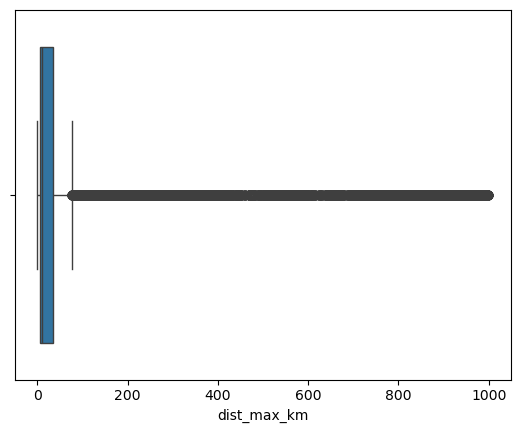

In [58]:
sns.boxplot(x=df_master_final["dist_max_km"])
plt.show()

Se muestra una gran cantidad de valores atipicos en la variable de distancia maxima. La mayoria de los clientes se concentran en rangos bajos de distancia pero existen muchos valores extremos que se extienden hasta casi 1000 km.
Esto nos reafirma la necesidad de aplicar tecnicas de tratamiento de outliers.

In [258]:
for col in categoricas:
    print(col, df_master_final[col].nunique())

FECHA_FIRST_DEPOSITO 1220
MONTH_LAST_DEPOSITO 19
FECHA_RANGO_IZQ 19
FECHA_LAST_DEPOSITO 214
SEXO 3
ESTADO_CIVIL 8
FECHA_NACIMIENTO 9011
FECHA_CLIENTE_DESDE 1595
CALLE 12445
COLONIA 7261
CIUDAD 506
CODIGO_ESTADO 36
CP_CALCULADO 3184
CLAVE_PAIS 8
DIRECCION 12631
direccion_sugerida 0
direccion 0
traffic_mode 3


Se identifican variables categoricas con alta cardinalidad, especialmente las relacionadas con direcciones.
Estas variables no son adecuadas para ser utilizadas directamente en modelos ya que generarian un numero excesivo de categorias.

# 5. Conclusiones EDA

Principales hallazgos:

- El ingreso presenta una distribucion sesgada con presencia de outliers.
